In [18]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [19]:
#Load Iris Data
iris = load_iris()
X = iris.data[:, 2:4]  # features
y = iris.target        # labels: 0, 1, 2

feature_names = iris.feature_names[2:4]

In [20]:
#%%
mask_2class = y < 2             # keep class 0 and 1
X_2 = X[mask_2class]
y_2 = y[mask_2class]

In [21]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2, y_2, test_size=0.3, random_state=42, stratify=y_2
)

In [22]:
mlp_2 = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=55
)

In [23]:
mlp_2.fit(X2_train, y2_train)

c:\Users\paris\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=55)

In [24]:
y2_pred = mlp_2.predict(X2_test)
print("2-class train accuracy:", mlp_2.score(X2_train, y2_train))
print("2-class test accuracy:", mlp_2.score(X2_test, y2_test))
print()

2-class train accuracy: 1.0
2-class test accuracy: 1.0



In [25]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

mlp_3 = MLPClassifier(
    hidden_layer_sizes=(20,),  # slightly bigger for 3 classes
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)
mlp_3.fit(X3_train, y3_train)

c:\Users\paris\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(20,), max_iter=1000, random_state=42)

In [26]:
print("3-class train accuracy:", mlp_3.score(X3_train, y3_train))
print("3-class test accuracy:", mlp_3.score(X3_test, y3_test))

3-class train accuracy: 0.9714285714285714
3-class test accuracy: 0.9111111111111111


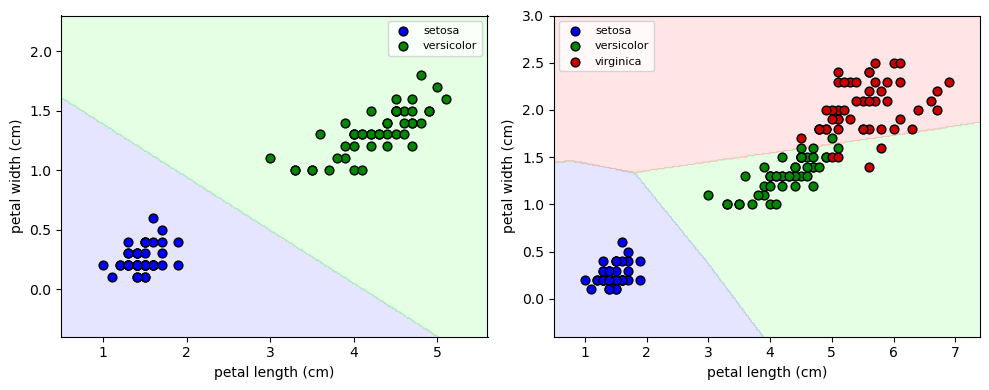

In [27]:
# -------------------------------------------------
# Helper: decision boundary plotting
# -------------------------------------------------
def plot_decision_boundary(ax, model, X, y, title, target_names=None):
    # Set up mesh over feature space
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    # Colour maps
    n_classes = len(np.unique(y))
    cmap_light = ListedColormap(["#AAAAFF", "#AAFFAA", "#FFAAAA"][:n_classes])
    cmap_bold = ["#0000FF", "#008800", "#CC0000"]

    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    # Scatter training data
    for i, class_label in enumerate(np.unique(y)):
        label = target_names[i] if target_names is not None else f"class {class_label}"
        ax.scatter(
            X[y == class_label, 0],
            X[y == class_label, 1],
            edgecolor="k",
            s=40,
            label=label,
            c=cmap_bold[i]
        )

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)

# -------------------------------------------------
# Plot both decision boundaries
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_decision_boundary(
    axes[0],
    mlp_2,
    X_2,
    y_2,
    "",
    target_names=iris.target_names[:2],
)

plot_decision_boundary(
    axes[1],
    mlp_3,
    X,
    y,
    "",
    target_names=iris.target_names,
)
plt.savefig('iris-nn-3.png')
plt.tight_layout()
plt.show()
